 SpendDNA – Your Wallet's Year-End Story

 Minor Project 2

Name: Rishitha HS
USN: 4RA23CI031
Batch: July
Date: 08 August 2026


Feature 1 – Transaction Parser

In this section, we will load the transaction dataset and clean the raw transaction data.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("DADS MP2 Dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

df.head()

Dataset loaded successfully!
Number of rows: 1328
Number of columns: 8


,Date,Time,Description,Type,Amount,Balance,Mode,Ref
0,2024-01-01,03:11,AMAZON SELLER SVCS,Debit,₹2462,678275.0,UPI,TXN190872
1,01-Jan-24,05:44,BHIM-BMTC,DR,50.00,681007.0,UPI,TXN143064
2,01-Jan-24,09:35,NEFT-TECHCRUSH LABS-SALARY MAY24,CR,₹84728,484728.0,NEFT,TXN246316
3,2024-01-01,14:07,UPI-AMAN-8934@OKAXIS,Debit,₹1828,-748745.0,UPI,TXN569226
4,01 Jan 2024,14:23,BHIM-BLINKIT,Debit,270.00,680737.0,UPI,TXN968962


In [2]:
# Remove ₹ symbol and commas from Amount
df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert Amount to number
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

print("Amount column cleaned successfully!")
print(df["Amount"].head())

Amount column cleaned successfully!
0     2462.0
1       50.0
2    84728.0
3     1828.0
4      270.0
Name: Amount, dtype: float64


In [3]:
# Convert Date column into standard date format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)

print("Date column cleaned successfully!")
print(df["Date"].head())

Date column cleaned successfully!
0   2024-01-01
1          NaT
2          NaT
3   2024-01-01
4          NaT
Name: Date, dtype: datetime64[ns]


In [4]:
# Convert different date formats safely
df["Date"] = pd.to_datetime(
    df["Date"].astype(str).str.strip(),
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

print("Date column cleaned successfully!")
print(df["Date"].head())
print("\nMissing dates:", df["Date"].isna().sum())

Date column cleaned successfully!
0   2024-01-01
1          NaT
2          NaT
3   2024-01-01
4          NaT
Name: Date, dtype: datetime64[ns]

Missing dates: 1184


In [5]:
print(df["Date"].astype(str).head(20).to_string())

0     2024-01-01
1            NaT
2            NaT
3     2024-01-01
4            NaT
5     2024-01-01
6     2024-01-01
7            NaT
8     2024-02-01
9            NaT
10           NaT
11           NaT
12           NaT
13           NaT
14           NaT
15           NaT
16    2024-02-01
17           NaT
18           NaT
19           NaT


In [6]:
# Reload the original CSV from the uploaded file
df = pd.read_csv("DADS MP2 Dataset.csv")

print("Original CSV reloaded successfully!")
print(df["Date"].head(20).to_string())

Original CSV reloaded successfully!
0      2024-01-01
1       01-Jan-24
2       01-Jan-24
3      2024-01-01
4     01 Jan 2024
5      2024-01-01
6      2024-01-01
7       01-Jan-24
8      2024-01-02
9        02/01/24
10       02/01/24
11      02-Jan-24
12       02/01/24
13    02 Jan 2024
14      02-Jan-24
15       02/01/24
16     2024-01-02
17       02/01/24
18      03-Jan-24
19       03/01/24


In [7]:
# Clean the Date column
df["Date"] = pd.to_datetime(
    df["Date"].astype(str).str.strip(),
    dayfirst=True,
    errors="coerce"
)

print("Date column cleaned successfully!")
print(df["Date"].head(20).to_string())

print("\nMissing dates:", df["Date"].isna().sum())

Date column cleaned successfully!
0    2024-01-01
1           NaT
2           NaT
3    2024-01-01
4           NaT
5    2024-01-01
6    2024-01-01
7           NaT
8    2024-02-01
9           NaT
10          NaT
11          NaT
12          NaT
13          NaT
14          NaT
15          NaT
16   2024-02-01
17          NaT
18          NaT
19          NaT

Missing dates: 1184


In [8]:
# Reload the original dataset
df = pd.read_csv("DADS MP2 Dataset.csv")

print("Original dataset reloaded.")

Original dataset reloaded.


In [9]:
from datetime import datetime

def clean_date(date_value):
    date_value = str(date_value).strip()

    formats = [
        "%Y-%m-%d",
        "%d-%b-%y",
        "%d %b %Y",
        "%d/%m/%y",
        "%d-%b-%Y",
        "%d %b %y"
    ]

    for fmt in formats:
        try:
            return datetime.strptime(date_value, fmt)
        except ValueError:
            continue

    return pd.NaT


df["Date"] = df["Date"].apply(clean_date)

print("Date column cleaned successfully!")
print(df["Date"].head(20).to_string())

print("\nMissing dates:", df["Date"].isna().sum())

Date column cleaned successfully!
0    2024-01-01
1    2024-01-01
2    2024-01-01
3    2024-01-01
4    2024-01-01
5    2024-01-01
6    2024-01-01
7    2024-01-01
8    2024-01-02
9    2024-01-02
10   2024-01-02
11   2024-01-02
12   2024-01-02
13   2024-01-02
14   2024-01-02
15   2024-01-02
16   2024-01-02
17   2024-01-02
18   2024-01-03
19   2024-01-03

Missing dates: 0


In [10]:
# Clean the Amount column
df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

print("Amount column cleaned successfully!")
print(df["Amount"].head(10).to_string())

print("\nMissing amounts:", df["Amount"].isna().sum())

Amount column cleaned successfully!
0     2462.0
1       50.0
2    84728.0
3     1828.0
4      270.0
5        NaN
6        NaN
7      482.0
8        NaN
9     3956.0

Missing amounts: 324


In [11]:
# Reload the original dataset
df = pd.read_csv("DADS MP2 Dataset.csv")

print("Original dataset reloaded.")

Original dataset reloaded.


In [12]:
# Show examples of the original Amount values
print(df["Amount"].head(30).to_string())

0         ₹2462
1         50.00
2        ₹84728
3         ₹1828
4        270.00
5       Rs. 625
6       Rs. 148
7          ₹482
8       Rs. 537
9          3956
10         ₹350
11         ₹311
12       258.00
13         ₹571
14       266.00
15         ₹405
16       267.00
17       Rs. 48
18        ₹1411
19     2,557.00
20         ₹537
21       878.00
22         ₹439
23         ₹238
24         1639
25      Rs. 272
26    Rs. 2,135
27        ₹2314
28      Rs. 159
29      Rs. 447


In [13]:
# Clean the Amount column

df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

print("Amount column cleaned successfully!")
print(df["Amount"].head(30).to_string())

print("\nMissing amounts:", df["Amount"].isna().sum())

Amount column cleaned successfully!
0      2462.0
1        50.0
2     84728.0
3      1828.0
4       270.0
5       625.0
6       148.0
7       482.0
8       537.0
9      3956.0
10      350.0
11      311.0
12      258.0
13      571.0
14      266.0
15      405.0
16      267.0
17       48.0
18     1411.0
19     2557.0
20      537.0
21      878.0
22      439.0
23      238.0
24     1639.0
25      272.0
26     2135.0
27     2314.0
28      159.0
29      447.0

Missing amounts: 0


In [14]:
# Clean Date column

from datetime import datetime

def clean_date(date_value):
    date_value = str(date_value).strip()

    formats = [
        "%Y-%m-%d",
        "%d-%b-%y",
        "%d %b %Y",
        "%d/%m/%y",
        "%d-%b-%Y",
        "%d %b %y"
    ]

    for fmt in formats:
        try:
            return datetime.strptime(date_value, fmt)
        except ValueError:
            continue

    return pd.NaT
df["Date"] = df["Date"].apply(clean_date)
df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
print("Date missing:", df["Date"].isna().sum())
print("Amount missing:", df["Amount"].isna().sum())

Date missing: 0
Amount missing: 0


In [15]:
print(df["Type"].value_counts())

Type
DR       670
Debit    652
CR         6
Name: count, dtype: int64


In [16]:
# Standardize transaction types

df["Type"] = df["Type"].replace({
    "DR": "Debit",
    "CR": "Credit"
})

print("Transaction types standardized!")
print(df["Type"].value_counts())

Transaction types standardized!
Type
Debit     1322
Credit       6
Name: count, dtype: int64


In [17]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate transactions:", duplicate_count)

Number of duplicate transactions: 18


## Feature 2 – Vendor Extractor

This feature extracts the merchant or vendor name from each transaction description and stores it in a new Vendor column. Common transaction prefixes and UPI identifiers are handled to obtain a cleaner vendor name. The vendor names are then standardized so that different descriptions referring to the same vendor are grouped together.

In [18]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print("Duplicate transactions removed:", before - after)
print("Rows remaining:", after)

Duplicate transactions removed: 18
Rows remaining: 1310


In [19]:
print(df["Description"].head(30).to_string())

0                   AMAZON SELLER SVCS
1                            BHIM-BMTC
2     NEFT-TECHCRUSH LABS-SALARY MAY24
3                 UPI-AMAN-8934@OKAXIS
4                         BHIM-BLINKIT
5                           BHIM ZEPTO
6               UPI-UBER-2426@HDFCBANK
7                         BHIM-BLINKIT
8                 POS SWIGGY BANGALORE
9                UPI-GROWWPAY@HDFCBANK
10                        OLA ELECTRIC
11                   BMS MOVIE TICKETS
12                       POS OLA-PRIME
13                    SWIGGY-INSTAMART
14                  UPI-STARBUCKS@AXIS
15                UPI-THIRDWAVE@OKAXIS
16                    ANI Technologies
17                       BMTC BUS PASS
18                        POS TRUFFLES
19                      FLIPKART INDIA
20               POS SWIGGY-RESTAURANT
21                   GROFERS INDIA P L
22                  POS UBER BANGALORE
23               POS SWIGGY-RESTAURANT
24               BANGALORE ELEC SUPPLY
25                       

In [20]:
def extract_vendor(description):
    text = str(description).strip()
    prefixes = ["UPI-", "POS ", "BHIM-", "NEFT-"]

    for prefix in prefixes:
        if text.startswith(prefix):
            text = text[len(prefix):]
            break

    if "@" in text:
        text = text.split("@")[0]
    if "-" in text:
        text = text.split("-")[0]

    return text.strip()
df["Vendor"] = df["Description"].apply(extract_vendor)
print("Vendor column created successfully!")
print(df[["Description", "Vendor"]].head(30).to_string())

Vendor column created successfully!
                         Description                 Vendor
0                 AMAZON SELLER SVCS     AMAZON SELLER SVCS
1                          BHIM-BMTC                   BMTC
2   NEFT-TECHCRUSH LABS-SALARY MAY24         TECHCRUSH LABS
3               UPI-AMAN-8934@OKAXIS                   AMAN
4                       BHIM-BLINKIT                BLINKIT
5                         BHIM ZEPTO             BHIM ZEPTO
6             UPI-UBER-2426@HDFCBANK                   UBER
7                       BHIM-BLINKIT                BLINKIT
8               POS SWIGGY BANGALORE       SWIGGY BANGALORE
9              UPI-GROWWPAY@HDFCBANK               GROWWPAY
10                      OLA ELECTRIC           OLA ELECTRIC
11                 BMS MOVIE TICKETS      BMS MOVIE TICKETS
12                     POS OLA-PRIME                    OLA
13                  SWIGGY-INSTAMART                 SWIGGY
14                UPI-STARBUCKS@AXIS              STARBUCKS
15  

In [21]:
print("Number of unique vendors:", df["Vendor"].nunique())
print("\nTop 20 vendors:")
print(df["Vendor"].value_counts().head(20))

Number of unique vendors: 173

Top 20 vendors:
Vendor
SWIGGY                86
ZOMATO                59
BLINKIT               32
SWIGGY BANGALORE      28
ZOMATO MEDIA P L      26
Swiggy*Order          26
RAPIDO                24
BHIM SWIGGY           23
ZOMATO BENGALURU      22
OLA CABS              21
UBER INDIA            20
OLA ELECTRIC          20
ZEPTO BANGALORE       19
Amazon Pay India      19
ANI Technologies      18
UBER SYSTEMS INDIA    18
BUNDL Tech P L        18
OLA                   18
ATM                   17
RAPIDO BIKE TAXI      17
Name: count, dtype: int64


In [22]:
def standardize_vendor(vendor):
    text = str(vendor).strip().upper()

    if "SWIGGY" in text or "BUNDL" in text:
        return "SWIGGY"

    elif "ZOMATO" in text:
        return "ZOMATO"

    elif "BLINKIT" in text or "GROFERS" in text:
        return "BLINKIT"

    elif "ZEPTO" in text:
        return "ZEPTO"

    elif "UBER" in text:
        return "UBER"

    elif "OLA" in text:
        return "OLA"

    elif "RAPIDO" in text:
        return "RAPIDO"

    elif "AMAZON" in text:
        return "AMAZON"

    elif "FLIPKART" in text:
        return "FLIPKART"

    elif "STARBUCKS" in text:
        return "STARBUCKS"

    elif "BMTC" in text:
        return "BMTC"

    elif "BESCOM" in text:
        return "BESCOM"

    else:
        return text
df["Vendor"] = df["Vendor"].apply(standardize_vendor)
print("Vendor names standardized!")
print("\nTop 20 vendors:")
print(df["Vendor"].value_counts().head(20))

Vendor names standardized!

Top 20 vendors:
Vendor
SWIGGY                   223
ZOMATO                   121
UBER                      71
AMAZON                    70
OLA                       69
ZEPTO                     58
BLINKIT                   55
FLIPKART                  43
STARBUCKS                 42
RAPIDO                    41
BMTC                      23
ANI TECHNOLOGIES          18
ATM                       17
RESTAURANT                17
INSTAMART BANGALORE       16
MYNTRA                    15
ROPPEN TRANSPORTATION     14
TUMMOC                    14
EMPIRE RESTAURANT         13
KIRANAKART TECH           13
Name: count, dtype: int64


## Feature 3 – Category Tagger

In this section, transactions are grouped into spending categories based on their description and vendor.

In [23]:
print(df[["Description", "Vendor"]].head(50).to_string(index=False))

                     Description                Vendor
              AMAZON SELLER SVCS                AMAZON
                       BHIM-BMTC                  BMTC
NEFT-TECHCRUSH LABS-SALARY MAY24        TECHCRUSH LABS
            UPI-AMAN-8934@OKAXIS                  AMAN
                    BHIM-BLINKIT               BLINKIT
                      BHIM ZEPTO                 ZEPTO
          UPI-UBER-2426@HDFCBANK                  UBER
                    BHIM-BLINKIT               BLINKIT
            POS SWIGGY BANGALORE                SWIGGY
           UPI-GROWWPAY@HDFCBANK              GROWWPAY
                    OLA ELECTRIC                   OLA
               BMS MOVIE TICKETS     BMS MOVIE TICKETS
                   POS OLA-PRIME                   OLA
                SWIGGY-INSTAMART                SWIGGY
              UPI-STARBUCKS@AXIS             STARBUCKS
            UPI-THIRDWAVE@OKAXIS             THIRDWAVE
                ANI Technologies      ANI TECHNOLOGIES
          

In [24]:
def categorize_transaction(row):
    text = (str(row["Description"]) + " " + str(row["Vendor"])).upper()

    if any(word in text for word in ["SWIGGY", "ZOMATO", "BLINKIT", "ZEPTO", "RESTAURANT", "STARBUCKS", "TRUFFLES"]):
        return "Food"

    elif any(word in text for word in ["UBER", "OLA", "RAPIDO", "BMTC", "TUMMOC", "TRANSPORTATION"]):
        return "Transport"

    elif any(word in text for word in ["AMAZON", "FLIPKART", "MYNTRA", "SHOPPING"]):
        return "Shopping"

    elif any(word in text for word in ["BESCOM", "ELECTRIC", "RECHARGE", "BILL", "RENT"]):
        return "Bills"

    elif any(word in text for word in ["MOVIE", "BMS", "PVR", "BOOKMYSHOW"]):
        return "Entertainment"

    elif any(word in text for word in ["PETROL", "FUEL", "HP PETROL"]):
        return "Fuel"

    elif any(word in text for word in ["SALARY", "NEFT", "CREDIT"]):
        return "Income"

    else:
        return "Other"
df["Category"] = df.apply(categorize_transaction, axis=1)
print("Category column created successfully!")
print(df[["Description", "Vendor", "Category"]].head(30).to_string(index=False))

Category column created successfully!
                     Description                Vendor      Category
              AMAZON SELLER SVCS                AMAZON      Shopping
                       BHIM-BMTC                  BMTC     Transport
NEFT-TECHCRUSH LABS-SALARY MAY24        TECHCRUSH LABS        Income
            UPI-AMAN-8934@OKAXIS                  AMAN         Other
                    BHIM-BLINKIT               BLINKIT          Food
                      BHIM ZEPTO                 ZEPTO          Food
          UPI-UBER-2426@HDFCBANK                  UBER     Transport
                    BHIM-BLINKIT               BLINKIT          Food
            POS SWIGGY BANGALORE                SWIGGY          Food
           UPI-GROWWPAY@HDFCBANK              GROWWPAY         Other
                    OLA ELECTRIC                   OLA     Transport
               BMS MOVIE TICKETS     BMS MOVIE TICKETS Entertainment
                   POS OLA-PRIME                   OLA     Transp

In [25]:
print(df["Category"].value_counts())

Category
Food             550
Other            340
Transport        232
Shopping         133
Bills             26
Entertainment     11
Fuel              11
Income             7
Name: count, dtype: int64


In [26]:
print(
    df[df["Category"] == "Other"][["Description", "Vendor", "Amount", "Type"]]
    .head(50)
    .to_string(index=False)
)

              Description                Vendor  Amount  Type
     UPI-AMAN-8934@OKAXIS                  AMAN  1828.0 Debit
    UPI-GROWWPAY@HDFCBANK              GROWWPAY  3956.0 Debit
     UPI-THIRDWAVE@OKAXIS             THIRDWAVE   405.0 Debit
         ANI Technologies      ANI TECHNOLOGIES   267.0 Debit
    BANGALORE ELEC SUPPLY BANGALORE ELEC SUPPLY  1639.0 Debit
                TWC INDIA             TWC INDIA   272.0 Debit
     UPI-AMAN-0816@OKAXIS                  AMAN  2314.0 Debit
    UPI-ANKIT-6430@OKAXIS                 ANKIT  2115.0 Debit
         UPI-CCD@HDFCBANK                   CCD   358.0 Debit
      INSTAMART BANGALORE   INSTAMART BANGALORE   290.0 Debit
        AVENUE SUPERMARTS     AVENUE SUPERMARTS  1248.0 Debit
    UPI-VIKAS-6060@OKAXIS                 VIKAS   329.0 Debit
    UPI-ZERODHA-COIN@AXIS               ZERODHA 15000.0 Debit
         UPI-DMART@OKAXIS                 DMART  1862.0 Debit
      POS CAFE COFFEE DAY       CAFE COFFEE DAY   179.0 Debit
        

In [27]:
def categorize_transaction(row):
    text = (str(row["Description"]) + " " + str(row["Vendor"])).upper()
    if any(word in text for word in [
        "GROWW", "ZERODHA", "COIN", "MUTUAL FUND", "INVESTMENT"
    ]):
        return "Investment"
    elif any(word in text for word in [
        "SWIGGY", "ZOMATO", "BLINKIT", "ZEPTO",
        "RESTAURANT", "STARBUCKS", "TRUFFLES",
        "CAFE COFFEE DAY", "COFFEE DAY", "MEGHANA FOODS",
        "DINEOUT", "THIRDWAVE", "CCD"
    ]):
        return "Food"
    elif any(word in text for word in [
        "UBER", "OLA", "RAPIDO", "BMTC",
        "TUMMOC", "TRANSPORTATION"
    ]):
        return "Transport"
    elif any(word in text for word in [
        "AMAZON", "AMZN", "FLIPKART", "FKART",
        "MYNTRA", "NYKAA", "DMART",
        "BIGBASKET", "AVENUE SUPERMARTS"
    ]):
        return "Shopping"
    elif any(word in text for word in [
        "BESCOM", "ELECTRIC", "BWSSB",
        "AIRTEL", "VI POSTPAID", "RECHARGE",
        "BILL", "RENT"
    ]):
        return "Bills"
    elif any(word in text for word in [
        "MOVIE", "BMS", "PVR", "BOOKMYSHOW",
        "NETFLIX", "SPOTIFY", "DISNEY HOTSTAR"
    ]):
        return "Entertainment"
    elif any(word in text for word in [
        "PETROL", "FUEL", "INDIAN OIL", "IOC"
    ]):
        return "Fuel"
    elif any(word in text for word in [
        "UPI-AMAN", "UPI-ANKIT", "UPI-VIKAS", "UPI-PRIYA"
    ]):
        return "Transfer"
    elif str(row["Type"]).upper() == "CREDIT":
        return "Income"

    else:
        return "Other"
df["Category"] = df.apply(categorize_transaction, axis=1)
print("Category column updated successfully!")
print("\nCategory counts:")
print(df["Category"].value_counts())

Category column updated successfully!

Category counts:
Category
Food             609
Transport        232
Shopping         202
Other            125
Bills             36
Entertainment     35
Fuel              28
Investment        23
Transfer          14
Income             6
Name: count, dtype: int64


## Feature 4 – Spending Overview

This feature provides a summary of the user's financial activity, including total income, total spending, average transaction amount, and spending by category.

In [28]:
total_income = df.loc[df["Type"] == "Credit", "Amount"].sum()
total_spending = df.loc[df["Type"] == "Debit", "Amount"].sum()
average_transaction = df["Amount"].mean()
print("Total Income: ₹", total_income)
print("Total Spending: ₹", total_spending)
print("Average Transaction: ₹", round(average_transaction, 2))

Total Income: ₹ 509774.0
Total Spending: ₹ 1678901.0
Average Transaction: ₹ 1670.74


In [29]:
category_spending = (
    df[df["Type"] == "Debit"]
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)
print("Spending by Category:")
print(category_spending)

Spending by Category:
Category
Shopping         649789.0
Food             353335.0
Investment       248160.0
Bills            135264.0
Other            114854.0
Fuel              89303.0
Transport         51860.0
Entertainment     18437.0
Transfer          17899.0
Name: Amount, dtype: float64


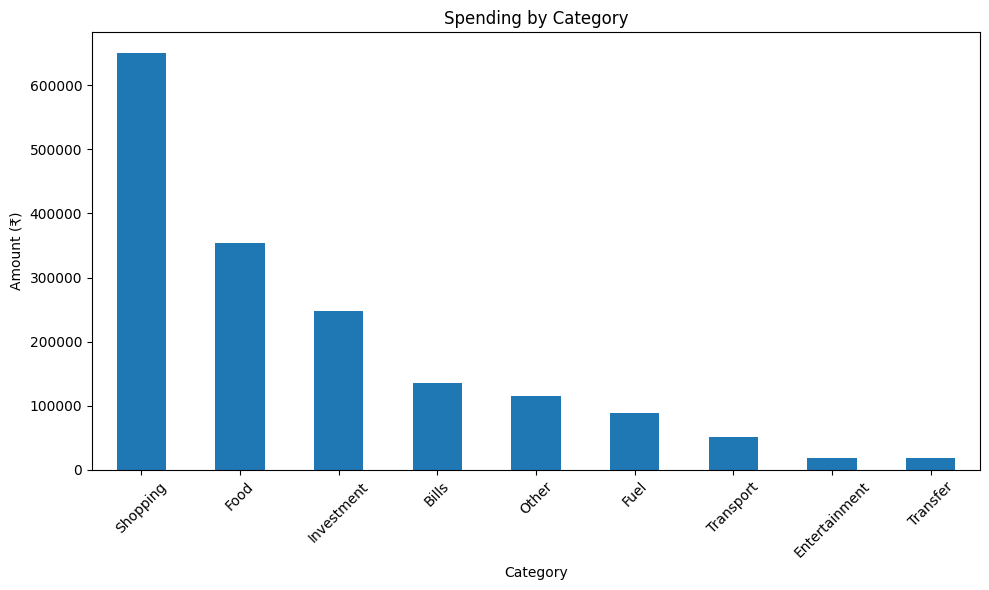

In [30]:
import matplotlib.pyplot as plt

# Create spending-by-category bar chart

category_spending.plot(kind="bar", figsize=(10, 6))

plt.title("Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [31]:
# Spending by vendor

vendor_spending = (
    df[df["Type"] == "Debit"]
    .groupby("Vendor")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 20 vendors by spending:")
print(vendor_spending.head(20))

Top 20 vendors by spending:
Vendor
AMAZON                  299462.0
FLIPKART                170745.0
IMPS                    108000.0
SWIGGY                   95523.0
IMPS ZERODHA             90000.0
ZERODHA                  90000.0
ZOMATO                   55316.0
MYNTRA                   53607.0
ATM                      45500.0
INDIAN OIL BANGALORE     41287.0
BLINKIT                  31995.0
ZEPTO                    28157.0
BANGALORE RESTAURANT     27528.0
GROWWPAY                 25888.0
UBER                     23770.0
AMZN                     23377.0
MEGHANA FOODS            22341.0
OLA                      21168.0
DINEOUT                  19825.0
HP PETROL STATION        17895.0
Name: Amount, dtype: float64


In [32]:
# Show top 20 vendors by spending

print("Top 20 vendors by spending:")
print(vendor_spending.head(20))

Top 20 vendors by spending:
Vendor
AMAZON                  299462.0
FLIPKART                170745.0
IMPS                    108000.0
SWIGGY                   95523.0
IMPS ZERODHA             90000.0
ZERODHA                  90000.0
ZOMATO                   55316.0
MYNTRA                   53607.0
ATM                      45500.0
INDIAN OIL BANGALORE     41287.0
BLINKIT                  31995.0
ZEPTO                    28157.0
BANGALORE RESTAURANT     27528.0
GROWWPAY                 25888.0
UBER                     23770.0
AMZN                     23377.0
MEGHANA FOODS            22341.0
OLA                      21168.0
DINEOUT                  19825.0
HP PETROL STATION        17895.0
Name: Amount, dtype: float64


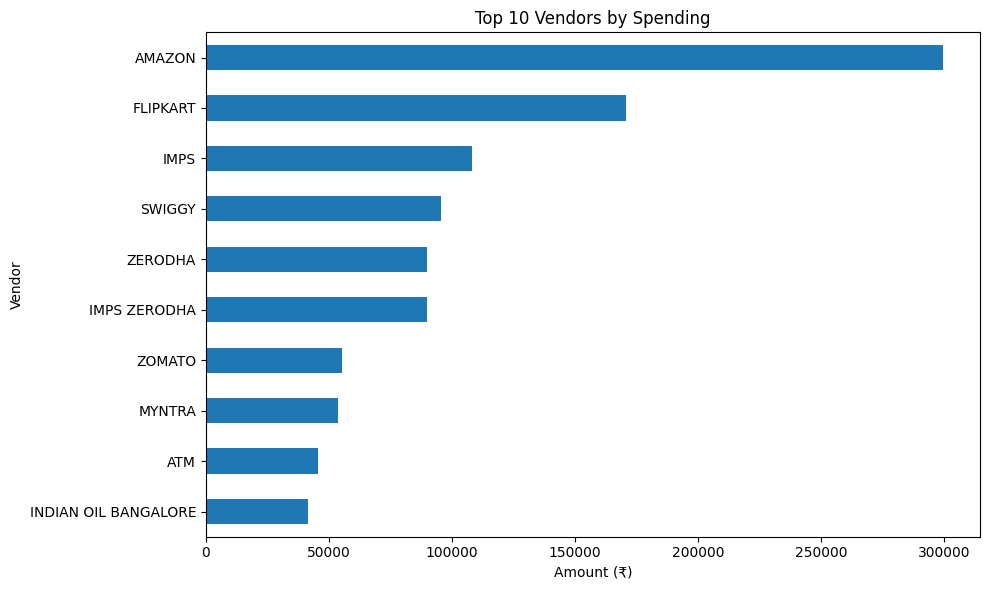

In [33]:
import matplotlib.pyplot as plt

# Top 10 vendors by spending

top_vendors = vendor_spending.head(10).sort_values()

top_vendors.plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 Vendors by Spending")
plt.xlabel("Amount (₹)")
plt.ylabel("Vendor")
plt.tight_layout()

plt.show()

In [34]:
# Monthly spending analysis

df["Month"] = df["Date"].dt.to_period("M")

monthly_spending = (
    df[df["Type"] == "Debit"]
    .groupby("Month")["Amount"]
    .sum()
)

print("Monthly Spending:")
print(monthly_spending)

Monthly Spending:
Month
2024-01    290767.0
2024-02    234071.0
2024-03    330458.0
2024-04    251382.0
2024-05    277306.0
2024-06    294917.0
Freq: M, Name: Amount, dtype: float64


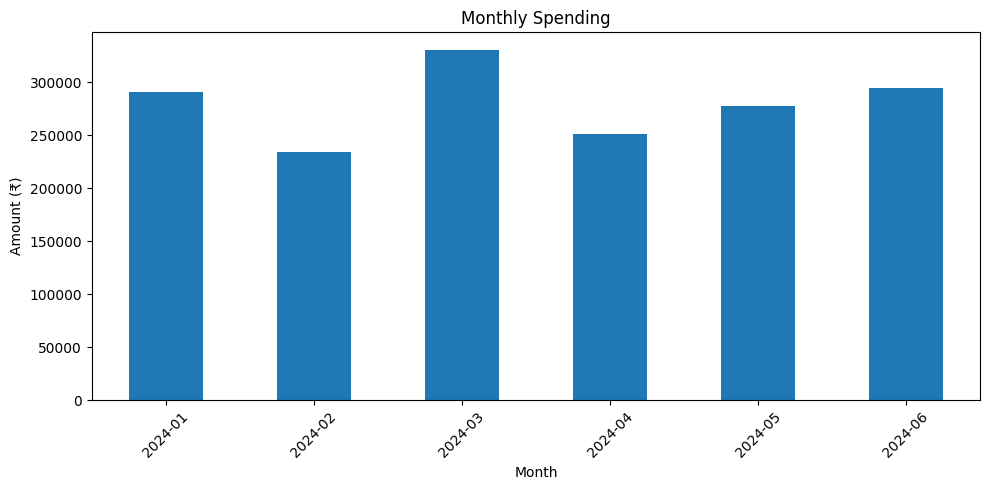

In [35]:
import matplotlib.pyplot as plt

monthly_spending.plot(kind='bar', figsize=(10, 5))

plt.title("Monthly Spending")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
highest_month = monthly_spending.idxmax()
highest_amount = monthly_spending.max()

print("Highest Spending Month:", highest_month)
print("Amount Spent: ₹", highest_amount)

Highest Spending Month: 2024-03
Amount Spent: ₹ 330458.0


In [37]:
category_spending = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

print("Spending by Category:")
print(category_spending)

Spending by Category:
Category
Shopping         649789.0
Income           509774.0
Food             353335.0
Investment       248160.0
Bills            135264.0
Other            114854.0
Fuel              89303.0
Transport         51860.0
Entertainment     18437.0
Transfer          17899.0
Name: Amount, dtype: float64


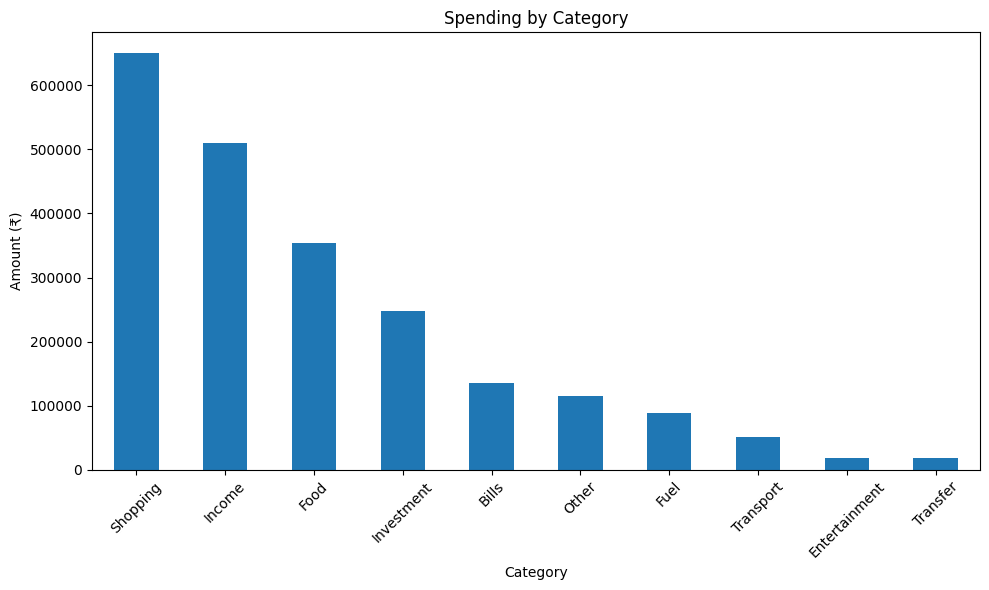

In [38]:
import matplotlib.pyplot as plt

category_spending.plot(kind='bar', figsize=(10, 6))

plt.title("Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
category_spending = df.groupby('Category')['Amount'].sum()
print(category_spending)

Category
Bills            135264.0
Entertainment     18437.0
Food             353335.0
Fuel              89303.0
Income           509774.0
Investment       248160.0
Other            114854.0
Shopping         649789.0
Transfer          17899.0
Transport         51860.0
Name: Amount, dtype: float64


In [40]:
highest_category = category_spending.idxmax()
highest_amount = category_spending.max()

print("Highest Spending Category:", highest_category)
print("Amount Spent: ₹", highest_amount)

Highest Spending Category: Shopping
Amount Spent: ₹ 649789.0


In [41]:
category_percentage = (category_spending / category_spending.sum()) * 100

print("Spending Percentage by Category:")
print(category_percentage.round(2))

Spending Percentage by Category:
Category
Bills             6.18
Entertainment     0.84
Food             16.14
Fuel              4.08
Income           23.29
Investment       11.34
Other             5.25
Shopping         29.69
Transfer          0.82
Transport         2.37
Name: Amount, dtype: float64


In [42]:
monthly_spending = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()

print("Monthly Spending:")
print(monthly_spending)

Monthly Spending:
Date
2024-01    375495.0
2024-02    318795.0
2024-03    415159.0
2024-04    336118.0
2024-05    362699.0
2024-06    380409.0
Freq: M, Name: Amount, dtype: float64


In [43]:
highest_month = monthly_spending.idxmax()
highest_month_amount = monthly_spending.max()

print("Highest Spending Month:", highest_month)
print("Amount Spent: ₹", highest_month_amount)

Highest Spending Month: 2024-03
Amount Spent: ₹ 415159.0


In [44]:
highest_mode = mode_spending.idxmax()
highest_mode_amount = mode_spending.max()

print("Highest Spending Payment Mode:", highest_mode)
print("Amount Spent: ₹", highest_mode_amount)

NameError: name 'mode_spending' is not defined

In [45]:
# Feature 5: Spending by Payment Mode

mode_spending = df.groupby('Mode')['Amount'].sum().sort_values(ascending=False)

print("Spending by Payment Mode:")
print(mode_spending)

Spending by Payment Mode:
Mode
UPI     1525401.0
NEFT     509774.0
IMPS     108000.0
ATM       45500.0
Name: Amount, dtype: float64


In [46]:
mode_spending = df.groupby('mode')['Amount'].sum().sort_values(ascending=False)

KeyError: 'mode'

In [47]:
mode_spending = df.groupby('Mode')['Amount'].sum().sort_values(ascending=False)

print("Spending by Payment Mode:")
print(mode_spending)

Spending by Payment Mode:
Mode
UPI     1525401.0
NEFT     509774.0
IMPS     108000.0
ATM       45500.0
Name: Amount, dtype: float64


In [48]:
highest_mode = mode_spending.idxmax()
highest_mode_amount = mode_spending.max()

print("Highest Spending Payment Mode:", highest_mode)
print("Amount Spent: ₹", highest_mode_amount)

Highest Spending Payment Mode: UPI
Amount Spent: ₹ 1525401.0


In [49]:
print(df.columns.tolist())

['Date', 'Time', 'Description', 'Type', 'Amount', 'Balance', 'Mode', 'Ref', 'Vendor', 'Category', 'Month']


In [50]:
# Feature 6 - Balance Trend Analysis

df['Date'] = pd.to_datetime(df['Date'])

daily_balance = df.groupby('Date')['Balance'].last()

print("Daily Balance:")
print(daily_balance)

Daily Balance:
Date
2024-01-01    677168.0
2024-01-02    676714.0
2024-01-03    666548.0
2024-01-04    663435.0
2024-01-05    652234.0
                ...   
2024-06-26   -299086.0
2024-06-27   -304868.0
2024-06-28   -305746.0
2024-06-29   -309512.0
2024-06-30   -312684.0
Name: Balance, Length: 182, dtype: float64


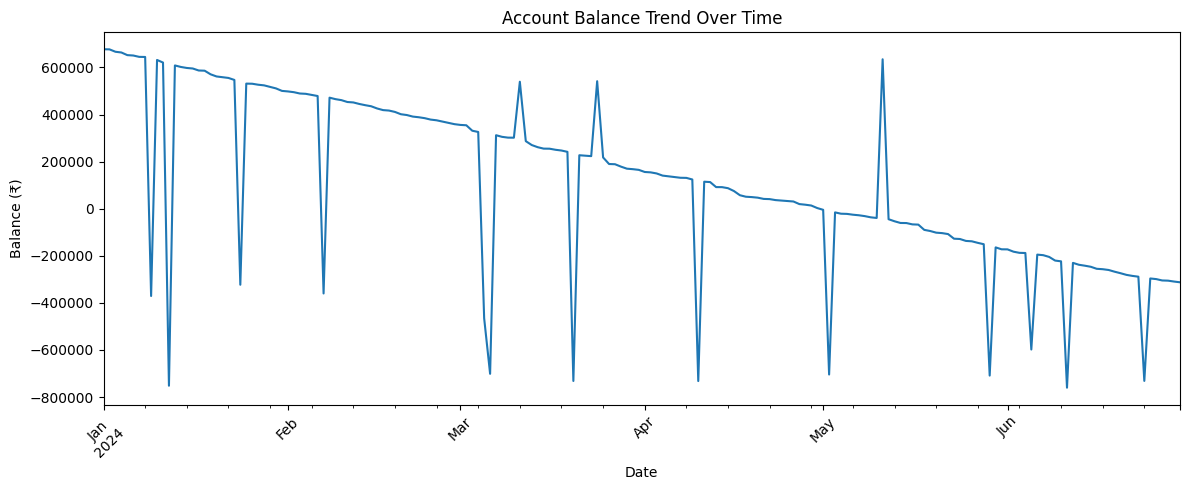

In [51]:
plt.figure(figsize=(12,5))

daily_balance.plot()

plt.title("Account Balance Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Balance (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [52]:
highest_balance = daily_balance.max()
lowest_balance = daily_balance.min()

highest_balance_date = daily_balance.idxmax()
lowest_balance_date = daily_balance.idxmin()

print("Highest Balance: ₹", highest_balance)
print("Date:", highest_balance_date)

print("\nLowest Balance: ₹", lowest_balance)
print("Date:", lowest_balance_date)

Highest Balance: ₹ 677168.0
Date: 2024-01-01 00:00:00

Lowest Balance: ₹ -760375.0
Date: 2024-06-11 00:00:00


In [53]:
# Feature 7 - Debit vs Credit Analysis

debit_credit = df.groupby('Type')['Amount'].sum()

print("Debit vs Credit:")
print(debit_credit)

Debit vs Credit:
Type
Credit     509774.0
Debit     1678901.0
Name: Amount, dtype: float64


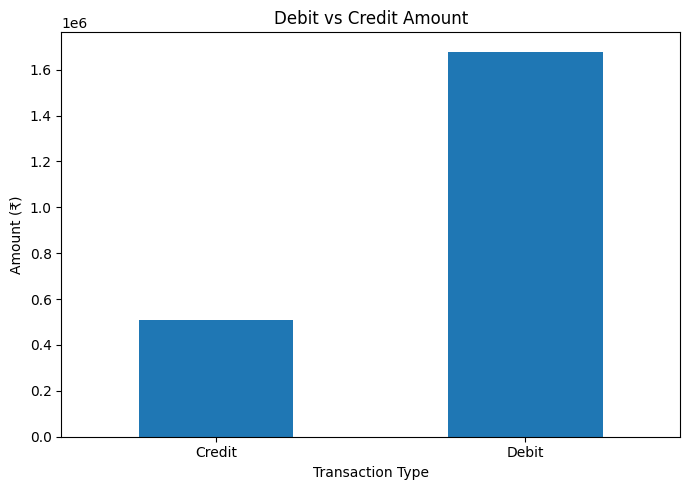

In [54]:
plt.figure(figsize=(7,5))

debit_credit.plot(kind='bar')

plt.title("Debit vs Credit Amount")
plt.xlabel("Transaction Type")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [55]:
higher_type = debit_credit.idxmax()
higher_amount = debit_credit.max()

print("Higher Transaction Type:", higher_type)
print("Total Amount: ₹", higher_amount)

Higher Transaction Type: Debit
Total Amount: ₹ 1678901.0


In [56]:
# Feature 8 - Transaction Count by Type

transaction_type_count = df['Type'].value_counts()

print("Number of Transactions by Type:")
print(transaction_type_count)

Number of Transactions by Type:
Type
Debit     1304
Credit       6
Name: count, dtype: int64


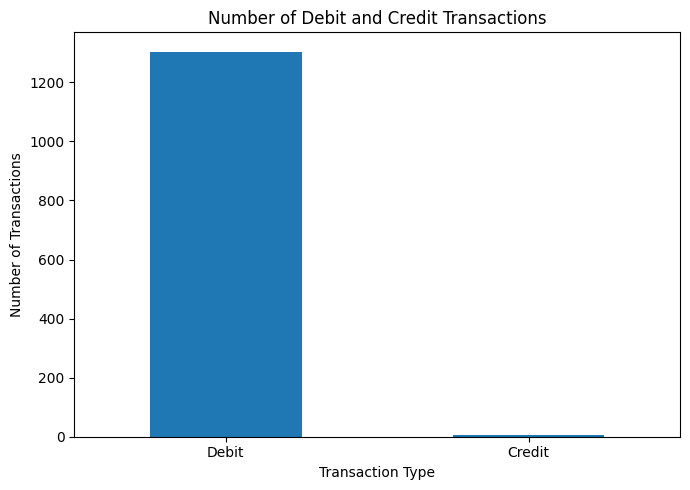

In [57]:
plt.figure(figsize=(7,5))

transaction_type_count.plot(kind='bar')

plt.title("Number of Debit and Credit Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [58]:
# Feature 9 - Average Transaction Amount

average_transaction = df['Amount'].mean()

print("Average Transaction Amount: ₹", round(average_transaction, 2))

Average Transaction Amount: ₹ 1670.74


In [59]:
average_by_type = df.groupby('Type')['Amount'].mean()

print("Average Amount by Transaction Type:")
print(average_by_type.round(2))

Average Amount by Transaction Type:
Type
Credit    84962.33
Debit      1287.50
Name: Amount, dtype: float64


In [60]:
# Feature 10 - Transaction Count by Payment Mode

mode_transaction_count = df['Mode'].value_counts()

print("Number of Transactions by Payment Mode:")
print(mode_transaction_count)

Number of Transactions by Payment Mode:
Mode
UPI     1281
ATM       17
NEFT       6
IMPS       6
Name: count, dtype: int64


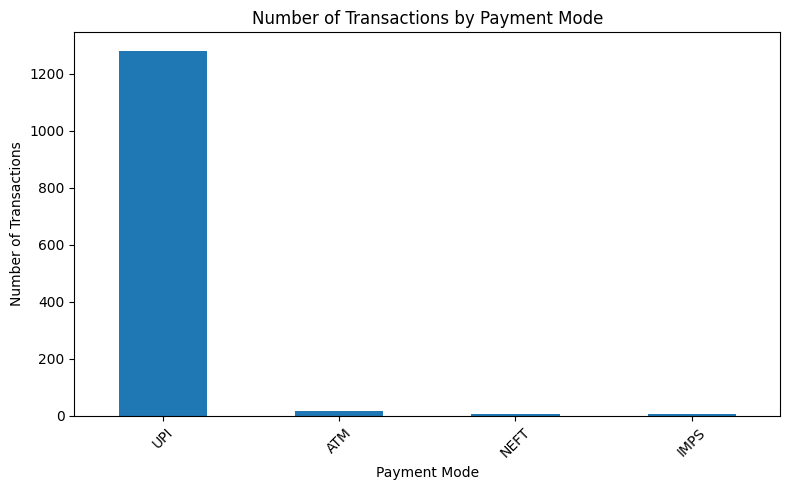

In [61]:
plt.figure(figsize=(8,5))

mode_transaction_count.plot(kind='bar')

plt.title("Number of Transactions by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

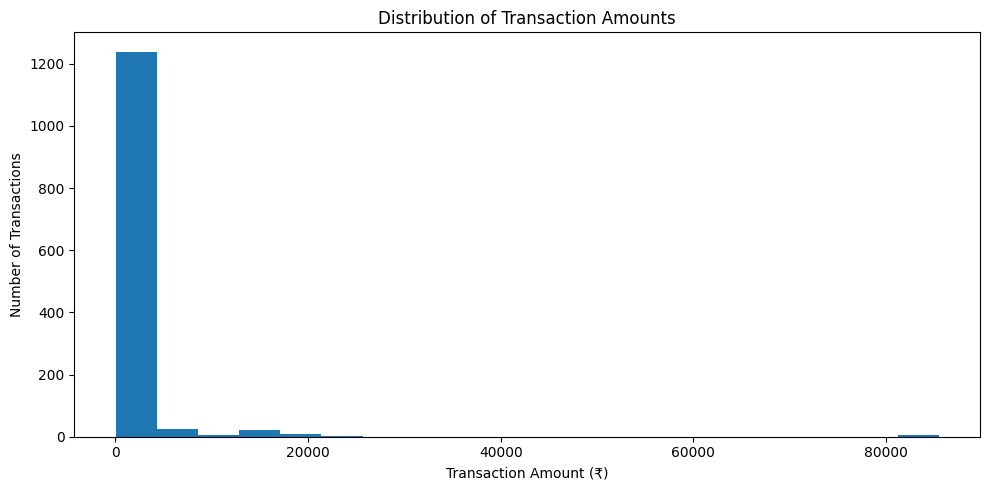

In [62]:
# Feature 11 - Transaction Amount Distribution

plt.figure(figsize=(10,5))

plt.hist(df['Amount'], bins=20)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [63]:
median_transaction = df['Amount'].median()

print("Median Transaction Amount: ₹", round(median_transaction, 2))

Median Transaction Amount: ₹ 477.0


In [64]:
# Feature 12 - Monthly Average Transaction Amount

monthly_average = df.groupby('Month')['Amount'].mean()

print("Monthly Average Transaction Amount:")
print(monthly_average.round(2))

Monthly Average Transaction Amount:
Month
2024-01    1714.59
2024-02    1496.69
2024-03    1913.18
2024-04    1514.05
2024-05    1619.19
2024-06    1769.34
Freq: M, Name: Amount, dtype: float64


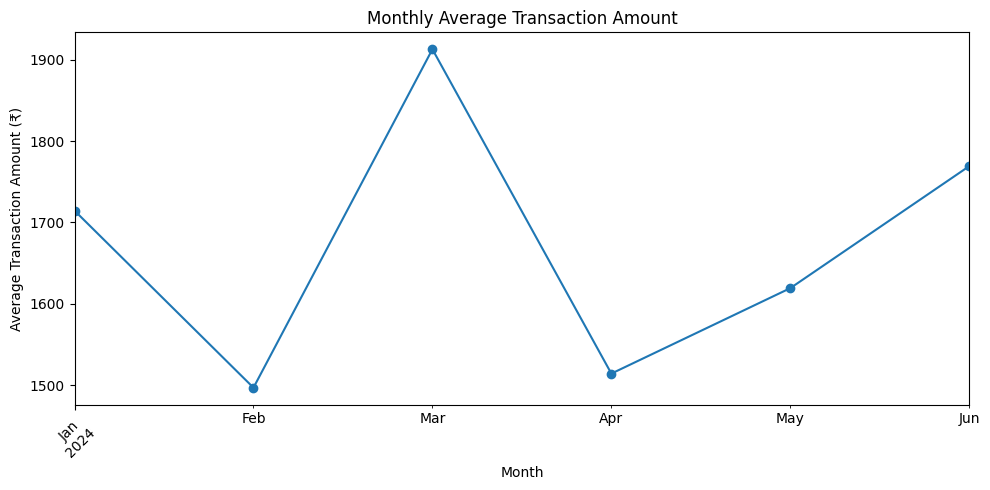

In [65]:
plt.figure(figsize=(10,5))

monthly_average.plot(kind='line', marker='o')

plt.title("Monthly Average Transaction Amount")
plt.xlabel("Month")
plt.ylabel("Average Transaction Amount (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [66]:
highest_avg_month = monthly_average.idxmax()
highest_avg_amount = monthly_average.max()

print("Month with Highest Average Transaction:", highest_avg_month)
print("Average Amount: ₹", round(highest_avg_amount, 2))

Month with Highest Average Transaction: 2024-03
Average Amount: ₹ 1913.18


In [67]:
# Feature 13 - Top 10 Highest Transactions

top_10_transactions = df.nlargest(10, 'Amount')

print("Top 10 Highest Transactions:")
print(top_10_transactions[['Date', 'Description', 'Amount', 'Type', 'Mode']])

Top 10 Highest Transactions:
           Date                       Description   Amount    Type  Mode
1099 2024-06-01  NEFT-TECHCRUSH LABS-SALARY MAY24  85492.0  Credit  NEFT
871  2024-05-01  NEFT-TECHCRUSH LABS-SALARY MAY24  85393.0  Credit  NEFT
651  2024-04-01  NEFT-TECHCRUSH LABS-SALARY MAY24  84736.0  Credit  NEFT
2    2024-01-01  NEFT-TECHCRUSH LABS-SALARY MAY24  84728.0  Credit  NEFT
221  2024-02-01  NEFT-TECHCRUSH LABS-SALARY MAY24  84724.0  Credit  NEFT
433  2024-03-01  NEFT-TECHCRUSH LABS-SALARY MAY24  84701.0  Credit  NEFT
1280 2024-06-26              AMAZONIN MARKETPLACE  22008.0   Debit   UPI
266  2024-02-07            UPI-AMAZONPAY@HDFCBANK  21986.0   Debit   UPI
470  2024-03-05            UPI-AMAZONPAY@HDFCBANK  19917.0   Debit   UPI
445  2024-03-02                         AMAZON IN  18273.0   Debit   UPI


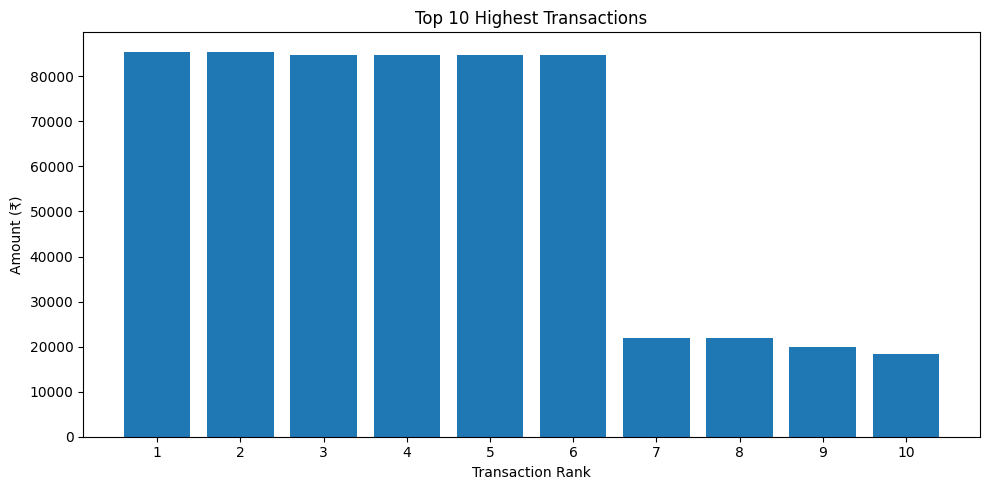

In [68]:
plt.figure(figsize=(10,5))

plt.bar(
    range(1, 11),
    top_10_transactions['Amount']
)

plt.title("Top 10 Highest Transactions")
plt.xlabel("Transaction Rank")
plt.ylabel("Amount (₹)")
plt.xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [69]:
# Feature 14 - Monthly Credit vs Debit Trend

monthly_type = df.groupby(['Month', 'Type'])['Amount'].sum().unstack(fill_value=0)

print("Monthly Credit vs Debit:")
print(monthly_type)

Monthly Credit vs Debit:
Type      Credit     Debit
Month                     
2024-01  84728.0  290767.0
2024-02  84724.0  234071.0
2024-03  84701.0  330458.0
2024-04  84736.0  251382.0
2024-05  85393.0  277306.0
2024-06  85492.0  294917.0


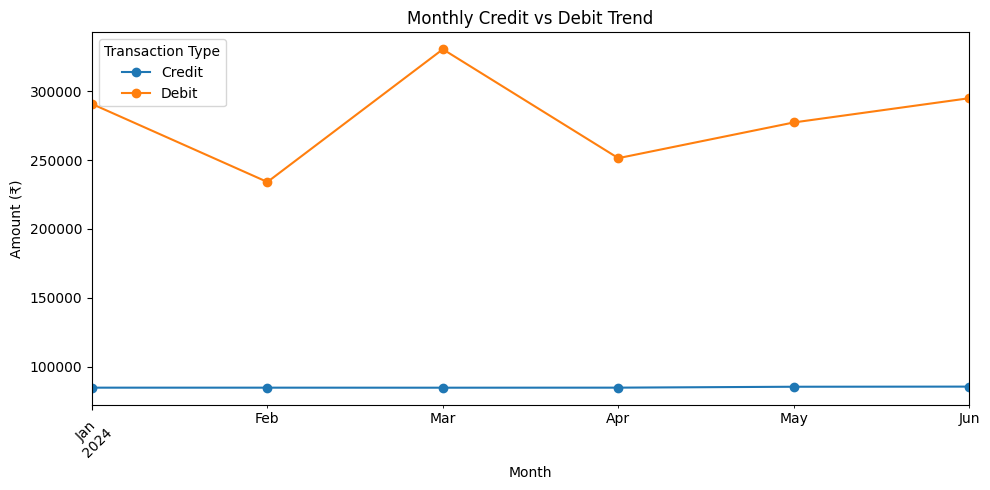

In [70]:
monthly_type.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.legend(title="Transaction Type")

plt.tight_layout()
plt.show()

In [71]:
# Feature 15 - Final Key Insights

print("========== FINAL PROJECT INSIGHTS ==========")

print("\n1. Total Transactions:", len(df))

print("2. Total Transaction Amount: ₹", round(df['Amount'].sum(), 2))

print("3. Average Transaction Amount: ₹", round(df['Amount'].mean(), 2))

print("4. Highest Transaction Amount: ₹", df['Amount'].max())

print("5. Lowest Transaction Amount: ₹", df['Amount'].min())

print("6. Highest Spending Month:", monthly_spending.idxmax())

print("7. Highest Spending Month Amount: ₹",
      round(monthly_spending.max(), 2))

print("8. Most Used Payment Mode:", mode_transaction_count.idxmax())

print("9. Most Frequent Transaction Type:",
      transaction_type_count.idxmax())

print("10. Highest Balance: ₹", daily_balance.max())

print("11. Lowest Balance: ₹", daily_balance.min())

========== FINAL PROJECT INSIGHTS ==========

1. Total Transactions: 1310
2. Total Transaction Amount: ₹ 2188675.0
3. Average Transaction Amount: ₹ 1670.74
4. Highest Transaction Amount: ₹ 85492.0
5. Lowest Transaction Amount: ₹ 10.0
6. Highest Spending Month: 2024-03
7. Highest Spending Month Amount: ₹ 415159.0
8. Most Used Payment Mode: UPI
9. Most Frequent Transaction Type: Debit
10. Highest Balance: ₹ 677168.0
11. Lowest Balance: ₹ -760375.0
